In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())

Ukuran dataset: (7043, 21)

Nama kolom:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [2]:
print("Informasi dataset:")
df.info()

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

In [3]:
print("Jumlah missing value setiap kolom:")
print(df.isnull().sum())

Jumlah missing value setiap kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [5]:
print("Jumlah nilai unik setiap kolom:")
print(df.nunique())

Jumlah nilai unik setiap kolom:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [6]:
print("Distribusi target Churn:")
print(df["Churn"].value_counts())

print("\nPersentase target Churn:")
print(df["Churn"].value_counts(normalize=True) * 100)

Distribusi target Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase target Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Jumlah nilai TotalCharges yang tidak dapat dikonversi menjadi numerik:",
      total_charges_numeric.isna().sum())

Jumlah nilai TotalCharges yang tidak dapat dikonversi menjadi numerik: 11


In [8]:
print(df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "TotalCharges", "Churn"]])

      customerID  tenure TotalCharges Churn
488   4472-LVYGI       0                 No
753   3115-CZMZD       0                 No
936   5709-LVOEQ       0                 No
1082  4367-NUYAO       0                 No
1340  1371-DWPAZ       0                 No
3331  7644-OMVMY       0                 No
3826  3213-VVOLG       0                 No
4380  2520-SGTTA       0                 No
5218  2923-ARZLG       0                 No
6670  4075-WKNIU       0                 No
6754  2775-SEFEE       0                 No


In [9]:
print("Statistik fitur numerik:")
print(df[["SeniorCitizen", "tenure", "MonthlyCharges"]].describe())

Statistik fitur numerik:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [10]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n=== {column} ===")
    print(df[column].value_counts())


=== customerID ===
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

=== gender ===
gender
Male      3555
Female    3488
Name: count, dtype: int64

=== Partner ===
Partner
No     3641
Yes    3402
Name: count, dtype: int64

=== Dependents ===
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

=== PhoneService ===
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

=== MultipleLines ===
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

=== InternetService ===
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

=== OnlineSecurity ===
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

=== OnlineBackup =

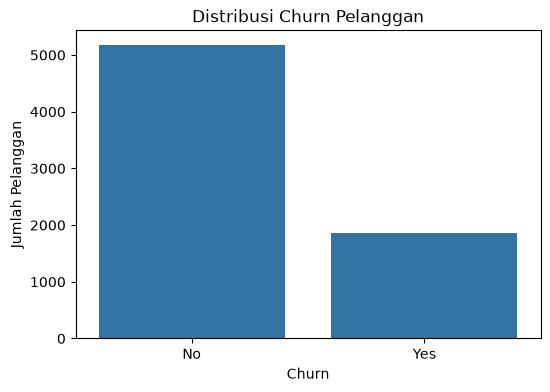

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Distribusi Churn Pelanggan")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.show()

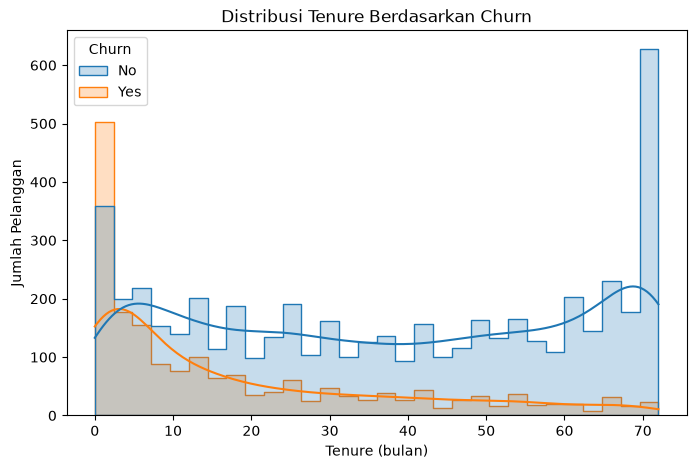

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribusi Tenure Berdasarkan Churn")
plt.xlabel("Tenure (bulan)")
plt.ylabel("Jumlah Pelanggan")
plt.show()

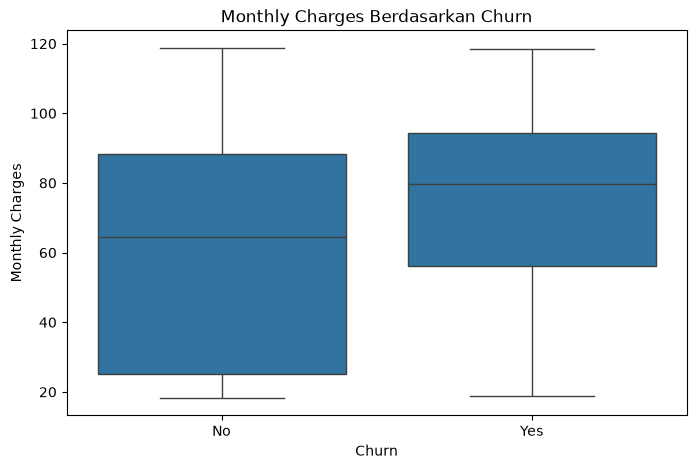

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Berdasarkan Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

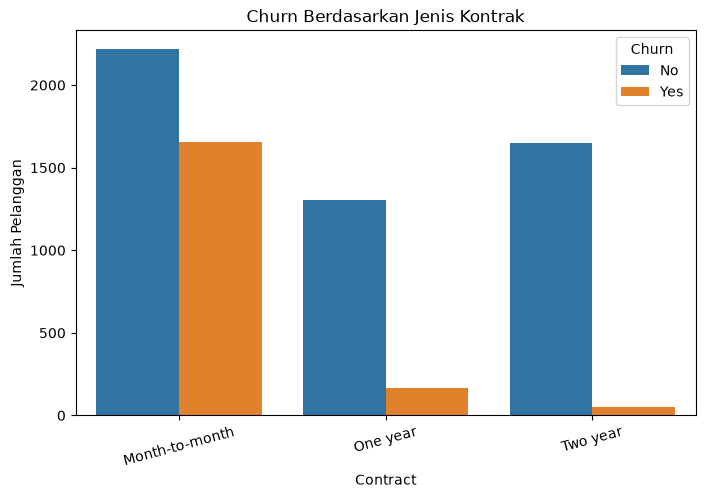

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn Berdasarkan Jenis Kontrak")
plt.xlabel("Contract")
plt.ylabel("Jumlah Pelanggan")
plt.xticks(rotation=15)
plt.show()

In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Jumlah nilai kosong pada TotalCharges:", df["TotalCharges"].isnull().sum())

Jumlah nilai kosong pada TotalCharges: 11


In [17]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Jumlah nilai kosong setelah preprocessing:")
print(df["TotalCharges"].isnull().sum())

Jumlah nilai kosong setelah preprocessing:
0


In [18]:
df = df.drop(columns=["customerID"])

print("Kolom setelah customerID dihapus:")
print(df.columns.tolist())

print("\nUkuran dataset:")
print(df.shape)

Kolom setelah customerID dihapus:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Ukuran dataset:
(7043, 20)


In [19]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Distribusi Churn setelah encoding:")
print(df["Churn"].value_counts())

print("\nTipe data Churn:")
print(df["Churn"].dtype)

Distribusi Churn setelah encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

Tipe data Churn:
int64


In [20]:
# Memisahkan fitur kategorikal dan numerik
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = df.select_dtypes(exclude=["object"]).columns.tolist()

print("Kolom kategorikal:")
print(categorical_columns)

print("\nKolom numerik:")
print(numerical_columns)

Kolom kategorikal:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Kolom numerik:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_data = encoder.fit_transform(df[categorical_columns])

encoded_columns = encoder.get_feature_names_out(categorical_columns)

df_encoded = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=df.index
)

print("Jumlah kolom hasil encoding:", len(encoded_columns))
print("\nContoh kolom hasil encoding:")
print(encoded_columns[:10])

Jumlah kolom hasil encoding: 41

Contoh kolom hasil encoding:
['gender_Female' 'gender_Male' 'Partner_No' 'Partner_Yes' 'Dependents_No'
 'Dependents_Yes' 'PhoneService_No' 'PhoneService_Yes' 'MultipleLines_No'
 'MultipleLines_No phone service']


In [22]:
# Mengambil fitur numerik tanpa target Churn
numerical_features = df[numerical_columns].drop(columns=["Churn"])

# Menggabungkan fitur numerik dan hasil One-Hot Encoding
X = pd.concat(
    [numerical_features, df_encoded],
    axis=1
)

# Target
y = df["Churn"]

print("Ukuran fitur X:", X.shape)
print("Ukuran target y:", y.shape)

print("\n5 baris pertama X:")
display(X.head())

print("\n5 baris pertama y:")
display(y.head())

Ukuran fitur X: (7043, 45)
Ukuran target y: (7043,)

5 baris pertama X:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,53.85,108.15,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0,45,42.30,1840.75,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,2,70.70,151.65,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0



5 baris pertama y:


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (5634, 45)
Ukuran X_test : (1409, 45)
Ukuran y_train: (5634,)
Ukuran y_test : (1409,)


In [24]:
print("Jumlah missing value pada X_train:", X_train.isnull().sum().sum())
print("Jumlah missing value pada X_test :", X_test.isnull().sum().sum())

print("\nJumlah missing value pada y_train:", y_train.isnull().sum())
print("Jumlah missing value pada y_test :", y_test.isnull().sum())

print("\nJumlah data duplikat pada X_train:", X_train.duplicated().sum())
print("Jumlah data duplikat pada X_test :", X_test.duplicated().sum())

Jumlah missing value pada X_train: 0
Jumlah missing value pada X_test : 0

Jumlah missing value pada y_train: 0
Jumlah missing value pada y_test : 0

Jumlah data duplikat pada X_train: 26
Jumlah data duplikat pada X_test : 2


### Pemeriksaan Duplikasi

Hasil pemeriksaan menunjukkan tidak terdapat baris duplikat pada dataset sebelum preprocessing.

Setelah proses encoding dan pembagian data, ditemukan beberapa baris dengan kombinasi fitur yang sama pada X_train dan X_test. Kondisi ini tidak langsung dianggap sebagai duplikasi data karena kolom customerID telah dihapus dan beberapa pelanggan dapat memiliki karakteristik yang sama.

Oleh karena itu, baris tersebut tetap dipertahankan agar tidak menghilangkan data pelanggan yang valid.

In [25]:
# Menggabungkan fitur dan target
df_preprocessed = pd.concat([X, y], axis=1)

print("Ukuran dataset hasil preprocessing:", df_preprocessed.shape)
print("\n5 data pertama:")
display(df_preprocessed.head())

Ukuran dataset hasil preprocessing: (7043, 46)

5 data pertama:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,29.85,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
1,0,34,56.95,1889.50,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,0,2,53.85,108.15,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,0,45,42.30,1840.75,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0
4,0,2,70.70,151.65,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1


In [26]:
import os

output_dir = "namadataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "telco_customer_churn_preprocessed.csv"
)

df_preprocessed.to_csv(output_path, index=False)

print("Dataset berhasil disimpan:")
print(output_path)

Dataset berhasil disimpan:
namadataset_preprocessing\telco_customer_churn_preprocessed.csv


In [27]:
df_check = pd.read_csv(output_path)

print("Ukuran dataset:", df_check.shape)
print("Jumlah missing value:", df_check.isnull().sum().sum())

Ukuran dataset: (7043, 46)
Jumlah missing value: 0


## Kesimpulan Preprocessing

Tahapan preprocessing yang dilakukan pada dataset Telco Customer Churn adalah:

1. Memuat dataset dan melakukan eksplorasi data.
2. Memeriksa informasi dataset, missing value, duplikasi, jumlah nilai unik, dan distribusi target.
3. Mengubah kolom `TotalCharges` menjadi tipe numerik.
4. Menangani 11 nilai kosong pada `TotalCharges` dengan nilai 0 karena seluruh data tersebut memiliki `tenure = 0`.
5. Menghapus kolom `customerID` karena merupakan identifier pelanggan.
6. Mengubah target `Churn` menjadi nilai numerik:
   - `No` → 0
   - `Yes` → 1
7. Melakukan One-Hot Encoding pada fitur kategorikal.
8. Memisahkan fitur (`X`) dan target (`y`).
9. Membagi dataset menjadi data training dan testing dengan rasio 80:20 menggunakan stratifikasi.
10. Melakukan pemeriksaan akhir terhadap missing value.
11. Menyimpan dataset hasil preprocessing dalam format CSV.

Dataset hasil preprocessing memiliki **7043 baris dan 46 kolom**, yang terdiri dari 45 fitur dan 1 kolom target `Churn`.

In [28]:
df_automated = pd.read_csv(
    "namadataset_preprocessing/telco_customer_churn_preprocessed.csv"
)

print("Ukuran dataset otomatis:", df_automated.shape)
print("Jumlah missing value:", df_automated.isnull().sum().sum())

print("\nNama kolom sama:",
      list(df_automated.columns) == list(df_preprocessed.columns))

print(
    "Isi dataset sama:",
    df_automated.equals(df_preprocessed)
)

Ukuran dataset otomatis: (7043, 46)
Jumlah missing value: 0

Nama kolom sama: True
Isi dataset sama: True
